# Branching Visualization

In [94]:
from rdflib import Graph, URIRef, Literal
import networkx as nx
from pyvis import network as net
import matplotlib.pyplot as plt

In [95]:
# Load the RDF graph
g = Graph()
# g.parse("coherence_graph.ttl", format="turtle")  # Replace with your RDF file
g.parse("coherence_graph.ttl", format="turtle")  # Replace with your RDF file

# Create a networkx graph
nxg = nx.DiGraph()  # Use DiGraph for directed graphs

In [66]:
# Iterate over the RDF graph to add nodes and edges with labels and colors
for subj, pred, obj in g:
    # Variables to store iteration values and text labels
    subj_text = None
    obj_text = None
    subj_iter = 0
    obj_iter = 0

    # Get the text labels and iteration values for subject and object if they are paths
    for s, p, o in g.triples((subj, URIRef("http://example.org/text"), None)):
        subj_text = str(o)
    for s, p, o in g.triples((obj, URIRef("http://example.org/text"), None)):
        obj_text = str(o)
    
    for s, p, o in g.triples((subj, URIRef("http://example.org/iteration"), None)):
        subj_iter = int(o)
    for s, p, o in g.triples((obj, URIRef("http://example.org/iteration"), None)):
        obj_iter = int(o)
    
    # Calculate color brightness based on iteration (higher iteration, brighter color)
    subj_color = f"rgb({min(255, 50 + subj_iter * 40)}, {min(255, 50 + subj_iter * 40)}, 255)"
    obj_color = f"rgb({min(255, 50 + obj_iter * 40)}, {min(255, 50 + obj_iter * 40)}, 255)"

    # Add nodes using the text label and color if available, otherwise use the URI without URL text
    if subj_text:
        if subj_text.startswith("http"):
            subj_text = ""  # If it's a URL, clear the text
        nxg.add_node(subj, label=subj_text, color=subj_color)
    else:
        subj_display = "" if str(subj).startswith("http") else str(subj)
        nxg.add_node(subj, label=subj_display, color=subj_color)

    if obj_text:
        if obj_text.startswith("http"):
            obj_text = ""  # If it's a URL, clear the text
        nxg.add_node(obj, label=obj_text, color=obj_color)
    else:
        obj_display = "" if str(obj).startswith("http") else str(obj)
        nxg.add_node(obj, label=obj_display, color=obj_color)

    # Add the edge without a label
    if pred.startswith("http"):
        nxg.add_edge(subj, obj, label=" ")
    else:
        nxg.add_edge(subj, obj, label=pred)

# Create a PyVis network and enable notebook display

graph = net.Network(notebook=True, cdn_resources='in_line', select_menu=True)
graph.show_buttons(filter_=['physics'])


graph.from_nx(nxg)

In [68]:
# Generate the HTML content
html_content = graph.generate_html()

# Save the HTML file with UTF-8 encoding
with open("graph.html", "w", encoding="utf-8") as f:
    f.write(html_content)

# Open "graph.html" in your browser
import webbrowser
webbrowser.open("graph.html")

True

# For Coherence Graph

In [76]:
# Load the RDF graph
g = Graph()
# g.parse("coherence_graph.ttl", format="turtle")  # Replace with your RDF file
g.parse("coherence_graph.ttl", format="turtle")  # Replace with your RDF file

# Create a networkx graph
nxg = nx.DiGraph()  # Use DiGraph for directed graphs

In [ ]:
# Iterate over the RDF graph to add nodes and edges with labels and colors
for subj, pred, obj in g:
    # Variables to store iteration values and text labels
    subj_text = None
    obj_text = None
    subj_iter = 0
    obj_iter = 0

    # Get the text labels and iteration values for subject and object if they are paths
    for s, p, o in g.triples((subj, URIRef("http://example.org/text"), None)):
        subj_text = str(o)
    for s, p, o in g.triples((obj, URIRef("http://example.org/text"), None)):
        obj_text = str(o)
    
    for s, p, o in g.triples((subj, URIRef("http://example.org/coherence_diff"), None)):
        subj_iter = float(o)
    for s, p, o in g.triples((obj, URIRef("http://example.org/coherence_diff"), None)):
        obj_iter = float(o)

    # Ensure color calculation uses wider scaling for better visualization
    max_color_value = 255
    base_color_value = 50  # Increase this to make colors brighter by default
    color_factor = 150       # Increase this to create more variation

    subj_color_value = min(max_color_value, base_color_value + subj_iter * color_factor)
    obj_color_value = min(max_color_value, base_color_value + obj_iter * color_factor)

    # RGB format ensures nodes are in varying shades of blue
    subj_color = f"rgb({subj_color_value}, {subj_color_value}, {subj_color_value})"
    obj_color = f"rgb({obj_color_value}, {obj_color_value}, {obj_color_value})"

    # Debug print to check color values
    print(f"Subject color: {subj_color}, Object color: {obj_color}")

    # Add nodes using the text label and color if available, otherwise use the URI without URL text
    if subj_text:
        if subj_text.startswith("http"):
            subj_text = ""  # If it's a URL, clear the text
        nxg.add_node(subj, label=subj_text, color=subj_color)
    else:
        subj_display = "" if str(subj).startswith("http") else str(subj)
        nxg.add_node(subj, label=subj_display, color=subj_color)

    if obj_text:
        if obj_text.startswith("http"):
            obj_text = ""  # If it's a URL, clear the text
        nxg.add_node(obj, label=obj_text, color=obj_color)
    else:
        obj_display = "" if str(obj).startswith("http") else str(obj)
        nxg.add_node(obj, label=obj_display, color=obj_color)

    # Add the edge without a label
    if pred.startswith("http"):
        nxg.add_edge(subj, obj, label=" ")
    else:
        nxg.add_edge(subj, obj, label=pred)

# Create a PyVis network and enable notebook display
graph = net.Network(notebook=True, cdn_resources='in_line', select_menu=True)
graph.show_buttons(["physics"])

# Load the NetworkX graph into PyVis for visualization
graph.from_nx(nxg)


Subject color: rgb(170.0, 170.0, 170.0), Object color: rgb(50, 50, 50)
Subject color: rgb(155.0, 155.0, 155.0), Object color: rgb(50, 50, 50)
Subject color: rgb(170.0, 170.0, 170.0), Object color: rgb(50, 50, 50)
Subject color: rgb(170.0, 170.0, 170.0), Object color: rgb(50, 50, 50)
Subject color: rgb(140.0, 140.0, 140.0), Object color: rgb(155.0, 155.0, 155.0)
Subject color: rgb(140.0, 140.0, 140.0), Object color: rgb(50, 50, 50)
Subject color: rgb(140.0, 140.0, 140.0), Object color: rgb(50, 50, 50)
Subject color: rgb(170.0, 170.0, 170.0), Object color: rgb(50, 50, 50)
Subject color: rgb(155.0, 155.0, 155.0), Object color: rgb(50, 50, 50)
Subject color: rgb(155.0, 155.0, 155.0), Object color: rgb(50, 50, 50)
Subject color: rgb(155.0, 155.0, 155.0), Object color: rgb(50, 50, 50)
Subject color: rgb(140.0, 140.0, 140.0), Object color: rgb(50, 50, 50)
Subject color: rgb(155.0, 155.0, 155.0), Object color: rgb(50, 50, 50)
Subject color: rgb(140.0, 140.0, 140.0), Object color: rgb(50, 50, 5

In [85]:
# Generate the HTML content
html_content = graph.generate_html()

# Save the HTML file with UTF-8 encoding
with open("graph.html", "w", encoding="utf-8") as f:
    f.write(html_content)

# Open "graph.html" in your browser
import webbrowser
webbrowser.open("graph.html")

True

# Perplexity Graph

In [99]:
# Load the RDF graph
g = Graph()
# g.parse("coherence_graph.ttl", format="turtle")  # Replace with your RDF file
g.parse("perplexity_graph.ttl", format="turtle")  # Replace with your RDF file

# Create a networkx graph
nxg = nx.DiGraph()  # Use DiGraph for directed graphs

In [100]:
# Calculate min and max values for perplexity_diff to normalize
perplexity_values = [float(o) for s, p, o in g.triples((None, URIRef("http://example.org/perplexity_diff"), None))]
min_perplexity = min(perplexity_values)
max_perplexity = max(perplexity_values)

def get_normalized_color(value, min_val, max_val):
    # Normalize the value to a 0-1 range and convert to a color gradient
    normalized_val = (value - min_val) / (max_val - min_val) if max_val != min_val else 0.5
    # Use matplotlib colormap for better gradient, e.g., 'coolwarm' or 'viridis'
    color = plt.cm.coolwarm(normalized_val)
    return f"rgb({int(color[0]*255)}, {int(color[1]*255)}, {int(color[2]*255)})"

# Iterate over RDF graph and add nodes and edges with normalized colors
for subj, pred, obj in g:
    # Variables to store iteration values and text labels
    subj_text, obj_text = None, None
    subj_iter, obj_iter = 0, 0

    # Get text labels for subject and object if they are paths
    for s, p, o in g.triples((subj, URIRef("http://example.org/text"), None)):
        subj_text = str(o)
    for s, p, o in g.triples((obj, URIRef("http://example.org/text"), None)):
        obj_text = str(o)

    # Get iteration values
    for s, p, o in g.triples((subj, URIRef("http://example.org/perplexity_diff"), None)):
        subj_iter = float(o)
    for s, p, o in g.triples((obj, URIRef("http://example.org/perplexity_diff"), None)):
        obj_iter = float(o)

    # Calculate colors based on normalized perplexity_diff values
    subj_color = get_normalized_color(subj_iter, min_perplexity, max_perplexity)
    obj_color = get_normalized_color(obj_iter, min_perplexity, max_perplexity)

    # Add nodes with text label and normalized color
    subj_display = "" if str(subj).startswith("http") else str(subj)
    nxg.add_node(subj, label=subj_text or subj_display, color=subj_color)
    
    obj_display = "" if str(obj).startswith("http") else str(obj)
    nxg.add_node(obj, label=obj_text or obj_display, color=obj_color)

    # Add edge with color based on object node
    if pred.startswith("http"):
        nxg.add_edge(subj, obj, label=" ", color=obj_color)
    else:
        nxg.add_edge(subj, obj, label=pred, color=obj_color)

# Create and display PyVis network
graph = net.Network(notebook=True, cdn_resources='in_line', select_menu=True)
graph.show_buttons(filter_=['physics'])
graph.from_nx(nxg)

In [101]:
# Generate the HTML content
html_content = graph.generate_html()

# Save the HTML file with UTF-8 encoding
with open("graph.html", "w", encoding="utf-8") as f:
    f.write(html_content)

# Open "graph.html" in your browser
import webbrowser
webbrowser.open("graph.html")

True

# Perplexity Visualization in Matplotlib

# 

In [102]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.cm as cm
from rdflib import Graph, URIRef

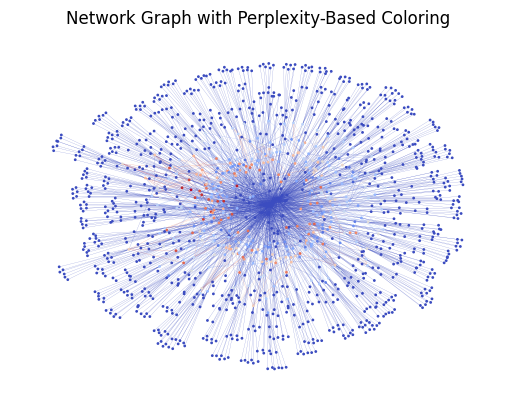

In [107]:
# Assuming `g` is your RDF graph loaded with triples
# Create a NetworkX graph
nxg = nx.Graph()

# Get perplexity values and calculate min/max for normalization
perplexity_values = [float(o) for s, p, o in g.triples((None, URIRef("http://example.org/perplexity_diff"), None))]
min_perplexity = min(perplexity_values)
max_perplexity = max(perplexity_values)

# Function to get color based on normalized value
def get_normalized_color(value, min_val, max_val):
    normalized_val = (value - min_val) / (max_val - min_val) if max_val != min_val else 0.5
    color = cm.coolwarm(normalized_val)  # Change 'coolwarm' to any other colormap if needed
    return (color[0], color[1], color[2], color[3])  # RGBA format for Matplotlib

# Add nodes and edges to the NetworkX graph with color attributes
for subj, pred, obj in g:
    # Get text labels and perplexity values
    subj_text, obj_text = None, None
    subj_iter, obj_iter = 0, 0

    # Retrieve text label for nodes
    for s, p, o in g.triples((subj, URIRef("http://example.org/text"), None)):
        subj_text = str(o)
    for s, p, o in g.triples((obj, URIRef("http://example.org/text"), None)):
        obj_text = str(o)

    # Retrieve perplexity_diff values for nodes
    for s, p, o in g.triples((subj, URIRef("http://example.org/perplexity_diff"), None)):
        subj_iter = float(o)
    for s, p, o in g.triples((obj, URIRef("http://example.org/perplexity_diff"), None)):
        obj_iter = float(o)

    # Calculate node colors based on normalized perplexity_diff
    subj_color = get_normalized_color(subj_iter, min_perplexity, max_perplexity)
    obj_color = get_normalized_color(obj_iter, min_perplexity, max_perplexity)

    # Add nodes to the NetworkX graph with color
    subj_display = "" if str(subj).startswith("http") else str(subj)
    obj_display = "" if str(obj).startswith("http") else str(obj)
    nxg.add_node(subj, label=subj_text or subj_display, color=subj_color)
    nxg.add_node(obj, label=obj_text or obj_display, color=obj_color)

    # Add edges, with edge color based on object node color
    edge_color = obj_color
    edge_label = pred if not pred.startswith("http") else " "
    nxg.add_edge(subj, obj, label=edge_label, color=edge_color)

# Draw the NetworkX graph with Matplotlib
pos = nx.spring_layout(nxg)  # Positioning nodes with spring layout for visualization

# Draw nodes with their specific colors
node_colors = [nxg.nodes[node]['color'] for node in nxg.nodes]
nx.draw_networkx_nodes(nxg, pos, node_color=node_colors, node_size=1)

# Draw edges with colors based on `perplexity_diff` of object nodes
edge_colors = [nxg.edges[edge]['color'] for edge in nxg.edges]
nx.draw_networkx_edges(nxg, pos, edge_color=edge_colors, width=0.1)

# Draw labels for nodes
# node_labels = {node: nxg.nodes[node]['label'] for node in nxg.nodes if nxg.nodes[node]['label']}
# nx.draw_networkx_labels(nxg, pos, labels=node_labels, font_size=10)


# Display plot
plt.title("Network Graph with Perplexity-Based Coloring")
plt.axis("off")
plt.show()